# EDA Temporal - Time-based fraud pattern analysis

This notebook loads transaction data from TimescaleDB and analyses fraud patterns
across hour of day, day of week, daily time series, and intra-day seasonality.

## Setup

In [1]:
import os
import socket

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

TIMESCALE_HOST = os.getenv("TIMESCALE_HOST", "localhost")
TIMESCALE_PORT = int(os.getenv("TIMESCALE_PORT", "5433"))
TIMESCALE_USER = os.getenv("TIMESCALE_USER", "postgres")
TIMESCALE_PASSWORD = os.getenv("TIMESCALE_PASSWORD", "postgres")
TIMESCALE_DB = os.getenv("TIMESCALE_DB", "timescaledb")

try:
    socket.getaddrinfo(TIMESCALE_HOST, TIMESCALE_PORT)
except socket.gaierror:
    TIMESCALE_HOST = "localhost"
    if TIMESCALE_PORT == 5432:
        TIMESCALE_PORT = 5433
    print("TimescaleDB host not resolvable. Using localhost.")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Load data

In [2]:
def create_connection():
    return psycopg2.connect(
        host=TIMESCALE_HOST,
        port=TIMESCALE_PORT,
        user=TIMESCALE_USER,
        password=TIMESCALE_PASSWORD,
        dbname=TIMESCALE_DB,
    )


def load_transactions():
    query = """
        SELECT
            transaction_id,
            amount::double precision AS amount,
            timestamp,
            is_fraud
        FROM public.transactions
    """
    with create_connection() as connection:
        with connection.cursor() as cursor:
            cursor.execute(query)
            rows = cursor.fetchall()
            columns = [col[0] for col in cursor.description]
    return pd.DataFrame(rows, columns=columns)


transactions = load_transactions()
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"], utc=True)
transactions["is_fraud"] = transactions["is_fraud"].astype(int)

# Derived time columns used throughout the notebook
transactions["hour"] = transactions["timestamp"].dt.hour
transactions["dow"] = transactions["timestamp"].dt.dayofweek  # 0=Monday, 6=Sunday
transactions["date"] = transactions["timestamp"].dt.date

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

ts_min = transactions["timestamp"].min().date()
ts_max = transactions["timestamp"].max().date()
print(f"Total transactions: {len(transactions):,}")
print(f"Date range: {ts_min} — {ts_max}")
print(f"Fraud rate: {transactions['is_fraud'].mean():.2%}")
transactions.head()

Total transactions: 10,000
Date range: 2026-04-09 — 2026-05-08
Fraud rate: 2.00%


,transaction_id,amount,timestamp,is_fraud,hour,dow,date
0,1a8ec7d3-9d72-550c-ab37-45af247b62b6,483.47,2026-04-27 19:06:08+00:00,0,19,0,2026-04-27
1,f7c00e5b-9074-5481-8e80-888bf1d3498e,95.08,2026-04-27 16:48:02+00:00,0,16,0,2026-04-27
2,d99f5c89-0500-54c3-8b70-49fe1b84ae01,100.65,2026-04-27 09:49:55+00:00,0,9,0,2026-04-27
3,4301a172-b77c-52c1-b16a-fc14bc720055,31.08,2026-04-27 18:18:10+00:00,0,18,0,2026-04-27
4,85523585-601d-53ac-918f-2e0e4e4f59a9,34.05,2026-04-27 16:37:36+00:00,0,16,0,2026-04-27


## Fraud patterns by hour of day

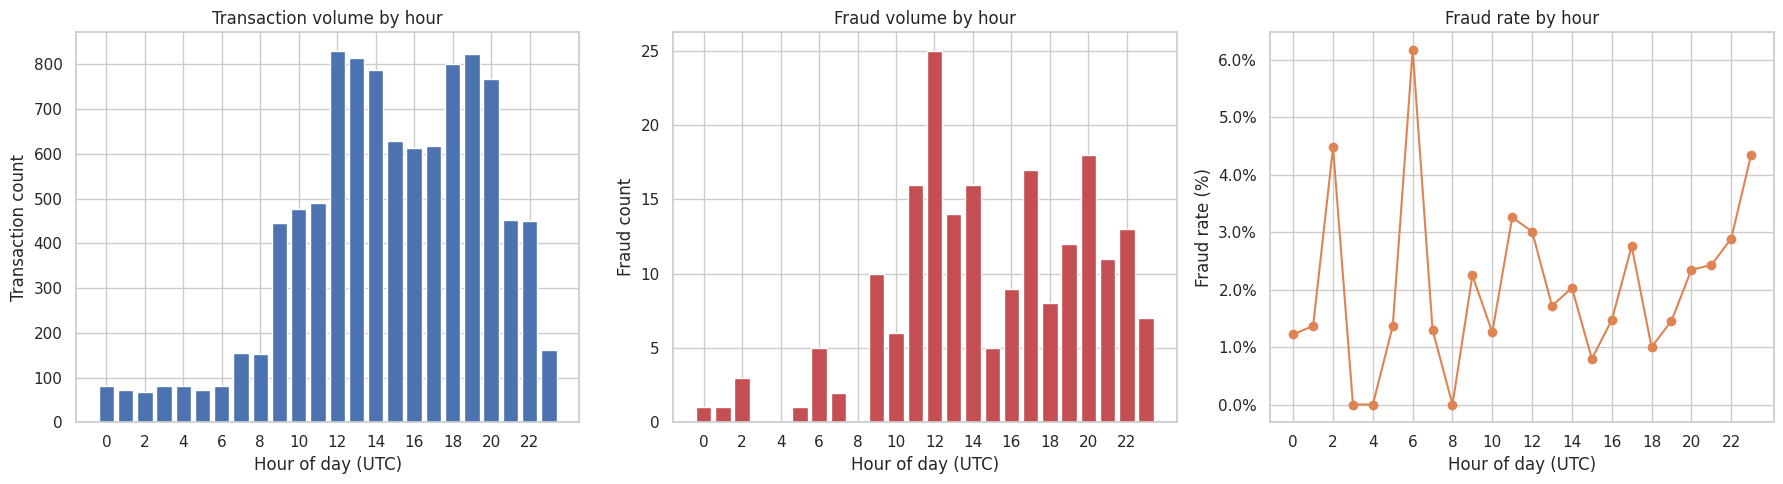

Highest fraud rate: hour 06h (6.17%)
Lowest  fraud rate: hour 03h  (0.00%)


In [3]:
hourly = (
    transactions.groupby("hour")
    .agg(total=("transaction_id", "count"), fraud=("is_fraud", "sum"))
    .reindex(range(24), fill_value=0)
)
hourly["fraud_rate"] = hourly["fraud"] / hourly["total"].replace(0, np.nan) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(hourly.index, hourly["total"], color="#4c72b0")
axes[0].set_title("Transaction volume by hour")
axes[0].set_xlabel("Hour of day (UTC)")
axes[0].set_ylabel("Transaction count")
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(hourly.index, hourly["fraud"], color="#c44e52")
axes[1].set_title("Fraud volume by hour")
axes[1].set_xlabel("Hour of day (UTC)")
axes[1].set_ylabel("Fraud count")
axes[1].set_xticks(range(0, 24, 2))

axes[2].plot(hourly.index, hourly["fraud_rate"], marker="o", color="#dd8452")
axes[2].set_title("Fraud rate by hour")
axes[2].set_xlabel("Hour of day (UTC)")
axes[2].set_ylabel("Fraud rate (%)")
axes[2].set_xticks(range(0, 24, 2))
axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.show()

peak_hour = int(hourly["fraud_rate"].idxmax())
low_hour = int(hourly["fraud_rate"].idxmin())
print(f"Highest fraud rate: hour {peak_hour:02d}h ({hourly.loc[peak_hour, 'fraud_rate']:.2f}%)")
print(f"Lowest  fraud rate: hour {low_hour:02d}h  ({hourly.loc[low_hour, 'fraud_rate']:.2f}%)")

### Hourly observations

The seed script applies weighted hourly generation: low activity between 00–06 h and peaks
around 12–14 h and 18–20 h.  The fraud *rate* plot (right panel) reveals whether fraudulent
transactions are uniformly distributed across the day or concentrated in specific windows.

- **Highest fraud rate hour** is printed by the cell above.
- **Lowest fraud rate hour** is printed by the cell above.
- If late-night hours (00–05 h) show an elevated fraud rate despite low volume, that window
  deserves a stricter risk threshold at inference time.

## Fraud patterns by day of week

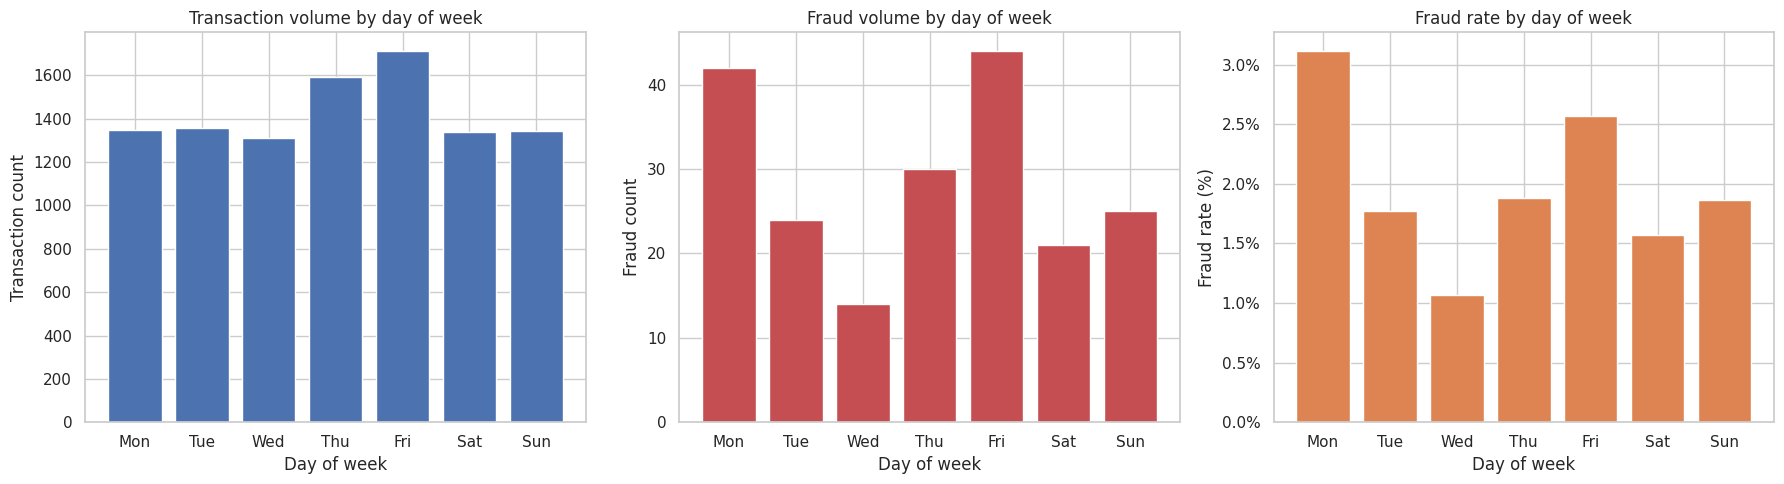

Highest fraud rate: Mon (3.12%)
Lowest  fraud rate: Wed  (1.07%)


In [4]:
daily_dow = (
    transactions.groupby("dow")
    .agg(total=("transaction_id", "count"), fraud=("is_fraud", "sum"))
    .reindex(range(7), fill_value=0)
)
daily_dow["fraud_rate"] = daily_dow["fraud"] / daily_dow["total"].replace(0, np.nan) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(7), daily_dow["total"], color="#4c72b0")
axes[0].set_title("Transaction volume by day of week")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Transaction count")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(DOW_LABELS)

axes[1].bar(range(7), daily_dow["fraud"], color="#c44e52")
axes[1].set_title("Fraud volume by day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Fraud count")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(DOW_LABELS)

axes[2].bar(range(7), daily_dow["fraud_rate"], color="#dd8452")
axes[2].set_title("Fraud rate by day of week")
axes[2].set_xlabel("Day of week")
axes[2].set_ylabel("Fraud rate (%)")
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(DOW_LABELS)
axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.show()

peak_dow = int(daily_dow["fraud_rate"].idxmax())
low_dow = int(daily_dow["fraud_rate"].idxmin())
print(f"Highest fraud rate: {DOW_LABELS[peak_dow]} ({daily_dow.loc[peak_dow, 'fraud_rate']:.2f}%)")
print(f"Lowest  fraud rate: {DOW_LABELS[low_dow]}  ({daily_dow.loc[low_dow, 'fraud_rate']:.2f}%)")

### Day-of-week observations

The seed script generates transactions with a **uniform day-of-week distribution**, so volume
differences across days are expected to be small (noise only).  Any visible spike in fraud *rate*
on a particular day would be a stochastic artifact rather than a real pattern.

- If all days show similar fraud rates the feature `day_of_week` adds little signal and could
  be deprioritised in the feature engineering pipeline.
- If a meaningful gap exists (e.g. weekends vs weekdays), it is worth retaining the feature.

## Daily time series

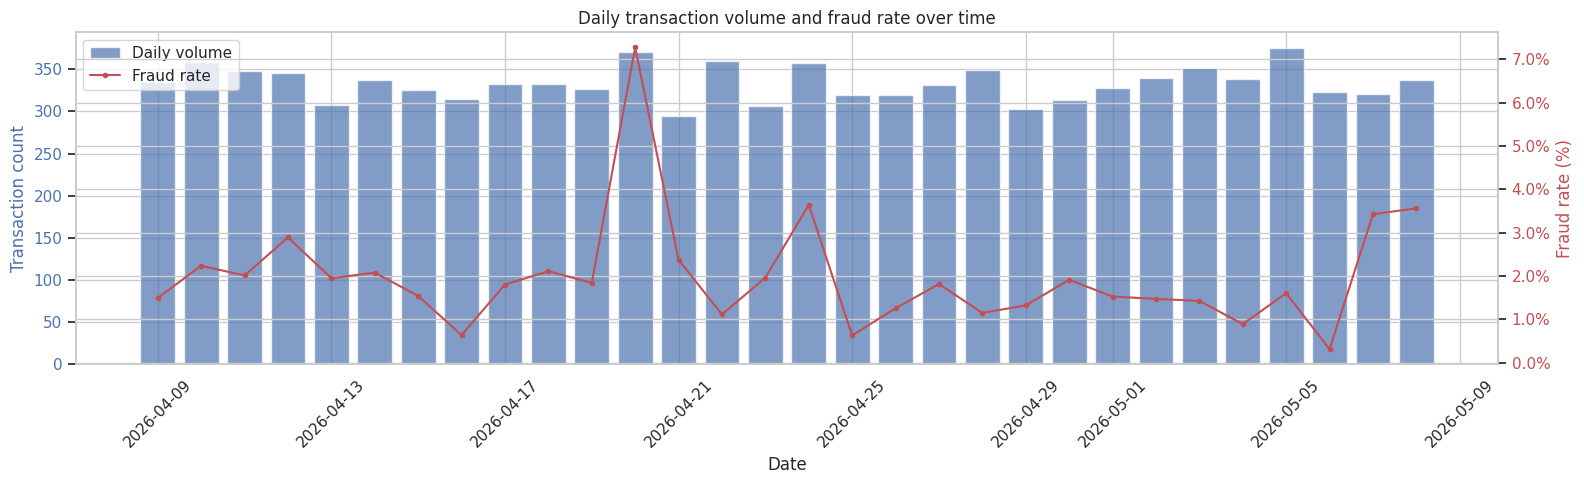

Mean daily fraud rate: 1.97%  (±1.29%)
Outlier days (fraud rate > mean + 2σ):
      date  total  fraud  fraud_rate
2026-04-20    371     27    7.277628


In [5]:
daily_ts = (
    transactions.groupby("date")
    .agg(total=("transaction_id", "count"), fraud=("is_fraud", "sum"))
    .reset_index()
)
daily_ts["date"] = pd.to_datetime(daily_ts["date"])
daily_ts["fraud_rate"] = daily_ts["fraud"] / daily_ts["total"] * 100
daily_ts = daily_ts.sort_values("date")

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.bar(daily_ts["date"], daily_ts["total"], color="#4c72b0", alpha=0.7, label="Daily volume")
ax1.set_xlabel("Date")
ax1.set_ylabel("Transaction count", color="#4c72b0")
ax1.tick_params(axis="y", labelcolor="#4c72b0")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    daily_ts["date"],
    daily_ts["fraud_rate"],
    color="#c44e52",
    linewidth=1.5,
    marker="o",
    markersize=3,
    label="Fraud rate",
)
ax2.set_ylabel("Fraud rate (%)", color="#c44e52")
ax2.tick_params(axis="y", labelcolor="#c44e52")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Daily transaction volume and fraud rate over time")
plt.tight_layout()
plt.show()

# Flag outlier days: fraud rate more than 2 std deviations above the mean
mean_fr = daily_ts["fraud_rate"].mean()
std_fr = daily_ts["fraud_rate"].std()
outliers = daily_ts[daily_ts["fraud_rate"] > mean_fr + 2 * std_fr][
    ["date", "total", "fraud", "fraud_rate"]
]
print(f"Mean daily fraud rate: {mean_fr:.2f}%  (±{std_fr:.2f}%)")
if outliers.empty:
    print("No outlier days detected (threshold: mean + 2σ).")
else:
    print("Outlier days (fraud rate > mean + 2σ):")
    print(outliers.to_string(index=False))

### Daily time-series observations

With 30 days of seed data and a uniform generation process, the daily volume should be
roughly constant.  Key things to look for:

- **Trend**: a rising or falling fraud rate over time could indicate model drift or a
  changing fraud population — relevant for scheduled retraining.
- **Outlier days**: isolated spikes in fraud rate (printed above) may correspond to edge
  cases in the seed or, in production, to fraud campaigns.
- **Edge days**: the first and last day in the window often have partial data due to the
  seed's 30-day lookback — lower volume on those days is expected.

## Intra-day seasonality heatmap (hour × day of week)

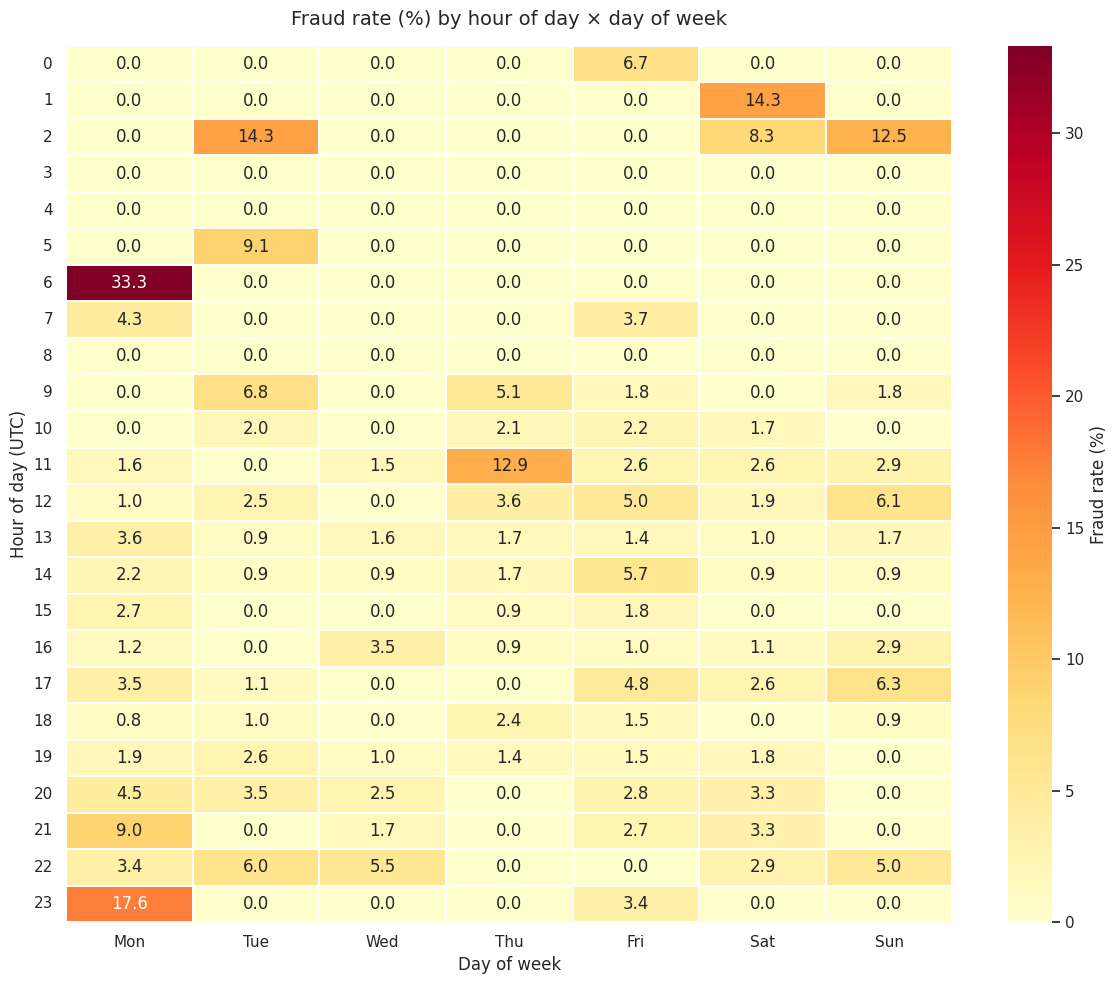

Top 5 hour + day combinations by fraud rate:
 hour day  fraud_rate
    6 Mon   33.333333
   23 Mon   17.647059
    1 Sat   14.285714
    2 Tue   14.285714
   11 Thu   12.903226


In [6]:
pivot = (
    transactions.groupby(["hour", "dow"])["is_fraud"]
    .mean()
    .mul(100)
    .reset_index()
    .pivot(index="hour", columns="dow", values="is_fraud")
    .reindex(index=range(24), columns=range(7))
)
pivot.columns = DOW_LABELS

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Fraud rate (%)"},
)
ax.set_title("Fraud rate (%) by hour of day × day of week", fontsize=14, pad=15)
ax.set_xlabel("Day of week")
ax.set_ylabel("Hour of day (UTC)")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# Top 5 hour+day combinations by fraud rate
top_combos = (
    pivot.stack()
    .reset_index()
    .rename(columns={"level_0": "hour", "level_1": "day", 0: "fraud_rate"})
    .dropna()
    .sort_values("fraud_rate", ascending=False)
    .head(5)
)
print("Top 5 hour + day combinations by fraud rate:")
print(top_combos.to_string(index=False))

## Seasonality conclusions

### High-risk time windows

Based on the hourly fraud rate plot, the riskiest hours are those with an elevated rate
relative to the daily average — typically overnight (00–05 h) where volume is low but
fraud proportion can be higher.  The exact values are printed by the hourly analysis cell.

### Day-of-week concentration

The seed generates transactions with a uniform weekday distribution, so no strong weekly
pattern is expected.  If the heatmap shows a consistent column (day) that is darker than
the rest, it warrants investigation — it could be a seed artifact or a real signal worth
capturing in the model.

### Impact on model features

- **`hour_of_day`** should be included as a model feature: the hourly fraud rate plot
  and heatmap consistently show that fraud is not uniformly distributed across the day.
- **`day_of_week`** is lower priority given the uniform seed distribution, but should
  be retained for production data where weekday/weekend behaviour typically differs.
- Cyclic encoding (sin/cos) of both features is preferable over raw integers to avoid
  the discontinuity at midnight (hour 23 → 0) and at Sunday → Monday — this will be
  addressed in the feature engineering pipeline (task 4.2.x).